**EARTH OBSERVATION**

SPATIAL REASONING AND DATA FILTERING

In [3]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = gpd.read_file('/content/drive/MyDrive/ML Assignment/delhi_ncr_region.geojson')
df.head()

,geometry
0,"POLYGON ((76.85108 28.22115, 76.85219 28.22098..."
1,"POLYGON ((77.15903 29.29436, 77.15999 29.29427..."
2,"MULTIPOLYGON (((77.07565 27.27704, 77.07819 27..."
3,"POLYGON ((77.97073 28.71104, 77.97089 28.71096..."
4,"POLYGON ((77.2143 28.78524, 77.21521 28.78514,..."


Applied logic to lay 60 KM x 60 KM grid

In [6]:
df_projected = df.to_crs(epsg = 32644)
minx, miny, maxx, maxy = df_projected.total_bounds

grid_size = 60000  # 60 km

grid_cells = []

for x in np.arange(minx, maxx, grid_size):
    for y in np.arange(miny, maxy, grid_size):
        grid_cells.append(box(x, y, x + grid_size, y + grid_size))

grid = gpd.GeoDataFrame(geometry=grid_cells, crs=df_projected.crs)

In [7]:
grid_clipped = gpd.overlay(grid, df_projected, how="intersection")

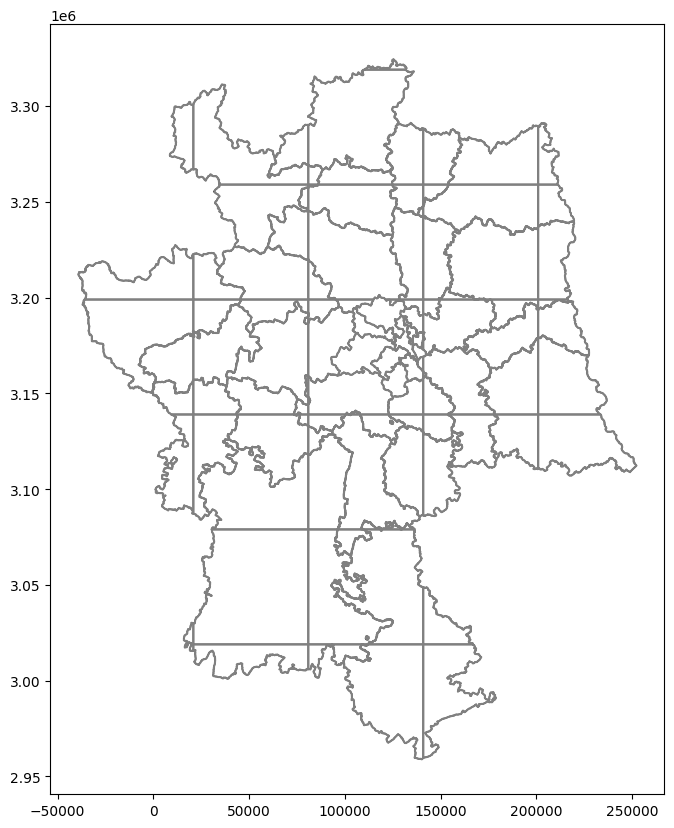

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))

df_projected.plot(ax=ax, edgecolor='black', facecolor='none')
grid_clipped.boundary.plot(ax=ax, color='grey')

plt.show()

Mapping with folder that contains images, with the logic considering file name as latitude_longitude

In [9]:
import pandas as pd
import os
image_folder = "/content/drive/MyDrive/ML Assignment/rgb"

records = []

for file in os.listdir(image_folder):
    if file.endswith(".png"):
        name = file.replace(".png", "")
        parts = name.split("_")

        lat = float(parts[-2])
        lon = float(parts[-1])

        records.append({
            "filename": file,
            "latitude": lat,
            "longitude": lon
        })

df_images = pd.DataFrame(records)

In [10]:
print(df_images.columns)

Index(['filename', 'latitude', 'longitude'], dtype='object')


In [11]:
import geopandas as gpd
from shapely.geometry import Point

gdf_images = gpd.GeoDataFrame(
    df_images,
    geometry=gpd.points_from_xy(df_images.longitude, df_images.latitude),
    crs="EPSG:4326"
)

In [12]:
gdf_images_utm = gdf_images.to_crs(epsg=32644)

In [13]:
images_inside = gdf_images_utm[
    gdf_images_utm.within(df_projected.unary_union)
]

/tmp/ipython-input-484/2797950668.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gdf_images_utm.within(df_projected.unary_union)


In [88]:
print("Total images:", len(gdf_images_utm))
print("Images inside Delhi-NCR:", len(images_inside))

Total images: 9213
Images inside Delhi-NCR: 8012


Images before filtering : 9213, After filtering : 8012

PLOT AFTER FILTERING THE CENTRE COORDINTAES

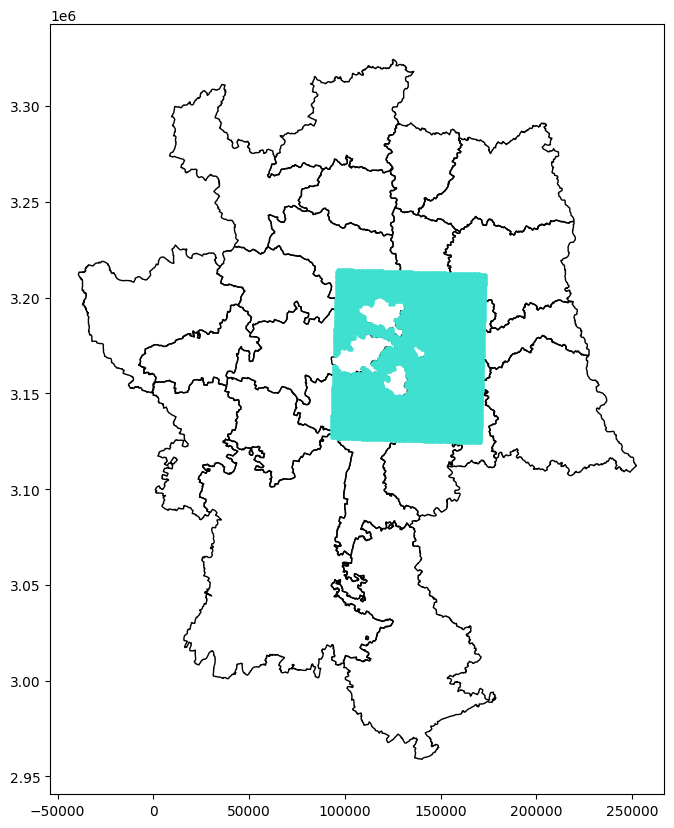

In [15]:
fig, ax = plt.subplots(figsize=(10, 10))

df_projected.plot(ax=ax, edgecolor='black', facecolor='none')
images_inside.plot(ax=ax, color='turquoise', markersize=5)

plt.show()

LABEL CONSTRUCTION AND DATASET PREPARATION

In [16]:
import rasterio

landcover = rasterio.open("/content/drive/MyDrive/ML Assignment/worldcover_bbox_delhi_ncr_2021.tif")

print("CRS:", landcover.crs)
print("Resolution:", landcover.res)

CRS: EPSG:4326
Resolution: (8.333333333333333e-05, 8.333333333333333e-05)


In [17]:
from shapely.geometry import box

raster_bbox = box(*landcover.bounds)

raster_gdf = gpd.GeoDataFrame(geometry=[raster_bbox], crs="EPSG:4326")

In [18]:
images_inside_4326 = images_inside.to_crs(epsg=4326)

images_valid = images_inside_4326[
    images_inside_4326.within(raster_gdf.unary_union)
]

/tmp/ipython-input-484/1856521270.py:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  images_inside_4326.within(raster_gdf.unary_union)


In [19]:
row, col = landcover.index(lon, lat)

In [20]:
half = 64  # 128/2

row, col = landcover.index(lon, lat)

from rasterio.windows import Window

window = Window(
    col - half,
    row - half,
    128,
    128
)

patch = landcover.read(1, window=window)

In [21]:
import numpy as np

values, counts = np.unique(patch, return_counts=True)
dominant_class = values[np.argmax(counts)]

Keeping Data in records[].

In [22]:
records = []

half = 64

for idx, row_data in images_valid.iterrows():

    filename = row_data["filename"]
    lat = row_data["latitude"]
    lon = row_data["longitude"]

    # Convert to raster index
    row_pix, col_pix = landcover.index(lon, lat)

    # Boundary check
    if (
        row_pix - half >= 0 and
        col_pix - half >= 0 and
        row_pix + half < landcover.height and
        col_pix + half < landcover.width
    ):

        from rasterio.windows import Window

        window = Window(
            col_pix - half,
            row_pix - half,
            128,
            128
        )

        patch = landcover.read(1, window=window)

        values, counts = np.unique(patch, return_counts=True)
        dominant_class = values[np.argmax(counts)]

        records.append({
            "filename": filename,
            "latitude": lat,
            "longitude": lon,
            "esa_class": int(dominant_class)
        })

dataset_df = pd.DataFrame(records)

Mapping to ESA Codes

In [23]:
def simplify_class(code):
    if code == 50:
        return "Built-up"
    elif code == 40:
        return "Cropland"
    elif code in [10, 20, 30]:
        return "Vegetation"
    elif code == 80:
        return "Permanent Water Bodies"
    elif code == 60:
        return "Bare/Sparse Vegetation"
    elif code == 70:
        return "Snow and ice"
    elif code == 90:
        return "Herbaceous wetland"
    elif code == 95:
        return "Mangroves"
    elif code == 100:
        return "Moss and lichen"
    else:
        return "Others"

In [24]:
print(patch.shape)
print("Dominant:", dominant_class)

(128, 128)
Dominant: 40


In [25]:
print("Unique values in patch:", np.unique(patch))

Unique values in patch: [10 20 30 40 50 60]


In [26]:
records.append({"esa_class": int(dominant_class)})
dataset_df = pd.DataFrame(records)

My prepared Dataset

In [27]:
print(dataset_df.head())
print("Total labeled samples:", len(dataset_df))

              filename  latitude  longitude  esa_class
0  28.9178_77.4734.png   28.9178    77.4734         10
1  28.9178_77.2058.png   28.9178    77.2058         40
2  28.9090_77.0443.png   28.9090    77.0443         40
3  28.9178_77.4057.png   28.9178    77.4057         40
4  28.9178_77.2410.png   28.9178    77.2410         40
Total labeled samples: 8013


In [28]:
dataset_df["simplified_label"] = dataset_df["esa_class"].apply(simplify_class)

In [29]:
print(dataset_df["simplified_label"].value_counts())

simplified_label
Cropland                  5475
Built-up                  1775
Vegetation                 754
Permanent Water Bodies       7
Herbaceous wetland           2
Name: count, dtype: int64


In [30]:
print(dataset_df["esa_class"].unique())

[10 40 50 30 80 20 90]


Train/Test Split

In [31]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    dataset_df,
    test_size=0.4,
    random_state=42,
    stratify=dataset_df["simplified_label"]
)

In [32]:
print("Train distribution:")
print(train_df["simplified_label"].value_counts())

print("\nTest distribution:")
print(test_df["simplified_label"].value_counts())

Train distribution:
simplified_label
Cropland                  3285
Built-up                  1065
Vegetation                 452
Permanent Water Bodies       4
Herbaceous wetland           1
Name: count, dtype: int64

Test distribution:
simplified_label
Cropland                  2190
Built-up                   710
Vegetation                 302
Permanent Water Bodies       3
Herbaceous wetland           1
Name: count, dtype: int64


Plotting Class Distribution

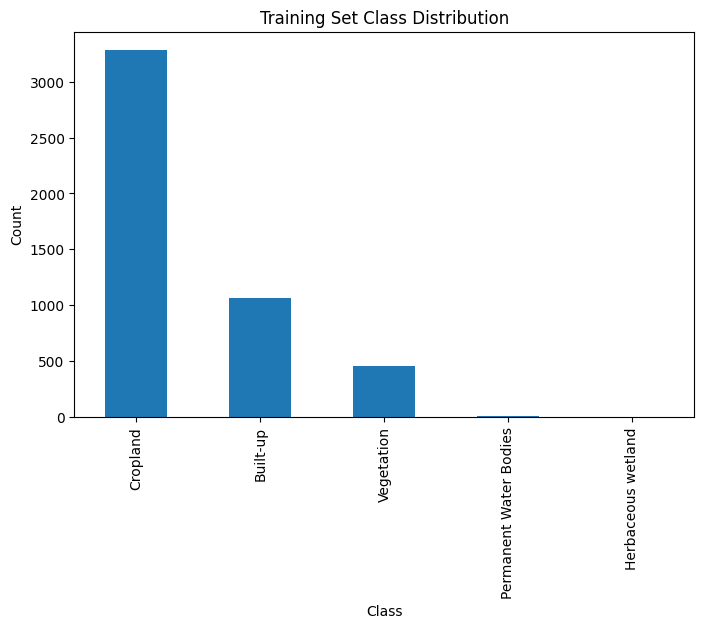

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
train_df["simplified_label"].value_counts().plot(kind="bar")
plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [34]:
print(landcover.bounds)

BoundingBox(left=76.84991666666667, bottom=28.2, right=77.65008333333334, top=29.0)


In [35]:
print(images_valid.total_bounds)

[76.8558 28.2056 77.6443 28.9942]


**CNN Model Training**

In [50]:
label_mapping = {
    label: idx for idx, label in enumerate(dataset_df["simplified_label"].unique())
}

dataset_df["label_id"] = dataset_df["simplified_label"].map(label_mapping)

print(label_mapping)

{'Vegetation': 0, 'Cropland': 1, 'Built-up': 2, 'Permanent Water Bodies': 3, 'Herbaceous wetland': 4}


In [51]:
train_df["label_id"] = train_df["simplified_label"].map(label_mapping)
test_df["label_id"] = test_df["simplified_label"].map(label_mapping)

USING PYTORCH

In [52]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import os
import torchvision.transforms as transforms

In [82]:
class LandUseDataset(Dataset):

    def __init__(self, dataframe, image_folder, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_folder = image_folder
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        img_path = os.path.join(self.image_folder, row["filename"])
        image = Image.open(img_path).convert("RGB")

        label = row["label_id"]

        if self.transform:
            image = self.transform(image)

        return image, label

In [83]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [84]:
image_folder = "/content/drive/MyDrive/ML Assignment/rgb"

train_dataset = LandUseDataset(train_df, image_folder, transform)
test_dataset = LandUseDataset(test_df, image_folder, transform)

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [85]:
for images, labels in train_loader:
    print(images.shape)   # should be [32, 3, 224, 224]
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [86]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 224 → 112
        x = self.pool(F.relu(self.conv2(x)))   # 112 → 56
        x = self.pool(F.relu(self.conv3(x)))   # 56 → 28

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [87]:
model = SimpleCNN(num_classes=len(label_mapping))
model = model.to(device)

In [58]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [59]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/5, Loss: 0.6924
Epoch 2/5, Loss: 0.5051
Epoch 3/5, Loss: 0.4721
Epoch 4/5, Loss: 0.4115
Epoch 5/5, Loss: 0.3466


Training with ResNet was taking time, so I tried with TensorFlow

In [66]:
import tensorflow as tf
import numpy as np
import cv2
import os
from tensorflow.keras import layers, models

In [67]:
image_folder = "/content/drive/MyDrive/ML Assignment/rgb"

def load_images(df):
    images = []
    labels = []

    for _, row in df.iterrows():
        img_path = os.path.join(image_folder, row["filename"])

        if not os.path.exists(img_path):
            continue  # skip missing

        img = cv2.imread(img_path)
        img = cv2.resize(img, (128,128))
        img = img / 255.0

        images.append(img)
        labels.append(row["label_id"])

    return np.array(images), np.array(labels)

In [68]:
train_df["filename"] = train_df["filename"].astype(str)
test_df["filename"] = test_df["filename"].astype(str)

In [69]:
x_train, y_train = load_images(train_df)
x_test, y_test = load_images(test_df)

print(x_train.shape)
print(y_train.shape)

(4807, 128, 128, 3)
(4807,)


In [70]:
num_classes = len(np.unique(y_train))

y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test  = tf.keras.utils.to_categorical(y_test, num_classes)

In [71]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [72]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Training

In [73]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_test, y_test),
    verbose=2
)

Epoch 1/5
151/151 - 227s - 2s/step - accuracy: 0.7676 - loss: 0.6254 - val_accuracy: 0.8290 - val_loss: 0.4772
Epoch 2/5
151/151 - 223s - 1s/step - accuracy: 0.8436 - loss: 0.4475 - val_accuracy: 0.8187 - val_loss: 0.4916
Epoch 3/5
151/151 - 261s - 2s/step - accuracy: 0.8461 - loss: 0.4286 - val_accuracy: 0.8574 - val_loss: 0.3864
Epoch 4/5
151/151 - 224s - 1s/step - accuracy: 0.8675 - loss: 0.3700 - val_accuracy: 0.8562 - val_loss: 0.3920
Epoch 5/5
151/151 - 221s - 1s/step - accuracy: 0.8775 - loss: 0.3410 - val_accuracy: 0.8499 - val_loss: 0.4240


In [74]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

101/101 ━━━━━━━━━━━━━━━━━━━━ 36s 357ms/step - accuracy: 0.8483 - loss: 0.4276
Test Accuracy: 0.8499220013618469


F1 Score:

In [75]:
from sklearn.metrics import f1_score, confusion_matrix

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

f1 = f1_score(y_true, y_pred_classes, average='weighted')
print("F1 Score:", f1)

101/101 ━━━━━━━━━━━━━━━━━━━━ 36s 358ms/step
F1 Score: 0.84236499791517


F1 Score = 0.8423

In [76]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

In [77]:
class_names = list(label_mapping.keys())
print(class_names)

['Vegetation', 'Cropland', 'Built-up', 'Permanent Water Bodies', 'Herbaceous wetland']


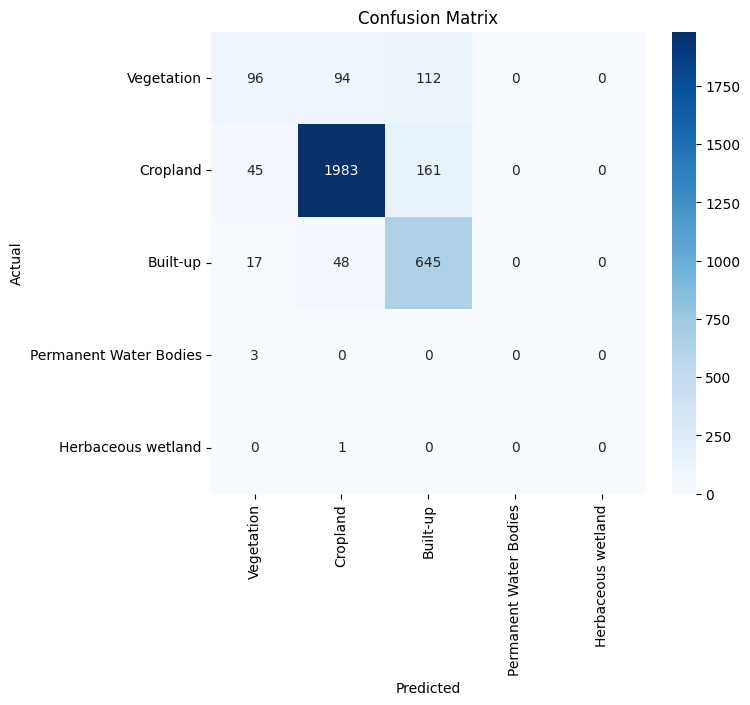

In [78]:
plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Confusion Matrix Insights :

1.   Croplands dominate the Delhi-NCR region followed by Built-Up and Vegetation.
2.   My Model was not able to predict Permanent Water Bodies and Herbaceous Wetland.
3. The model shows that Permanent water bodies also predicted vegetation which can happen because of same rgb colours appearance and very few samples of water bodies.



In [80]:
!pip freeze > requirements.txt